<a href="https://colab.research.google.com/github/unnatig330-ug/Fake-News-Detection-using-Machine_Learning_-Learning/blob/main/%F0%9F%93%84Project_Fake_News_Detection_using_Machine_Learning_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project📄: Fake News Detection using Machine Learning**

### **Step 1: Introduction**

Fake news has become a major problem because misleading information can spread rapidly through digital platforms. The objective of this project is to develop a Machine Learning model that can classify news articles as Fake or Real. In this project, news text is converted into numerical features using TF-IDF and two Machine Learning algorithms, Logistic Regression and Random Forest, are used for classification. The models are evaluated using accuracy, precision, recall, F1-score and confusion-matrix heatmaps.

# Project Objective

The main objective of this project is to develop a Machine Learning-based system for detecting whether a news article is **Fake or Real**.

The project aims to:

- Analyze and classify news articles using their textual content.
- Convert news text into numerical features using **TF-IDF Vectorization**.
- Apply and compare two Machine Learning algorithms:
  - Logistic Regression
  - Random Forest
- Evaluate model performance using Accuracy, Precision, Recall and F1-score.
- Visualize model performance using graphs and confusion-matrix heatmaps.
- Use the trained model to predict whether a new news article is Fake or Real.

# Technology Stack

The following technologies and Python libraries are used in this project:

| Technology / Library | Purpose |
|---|---|
| Python | Programming language used for the project |
| Google Colab | Development and execution environment |
| Pandas | Data loading and data manipulation |
| NumPy | Numerical operations |
| Matplotlib | Data visualization |
| Seaborn | Statistical visualization and heatmaps |
| Scikit-learn | Machine Learning implementation |
| TF-IDF Vectorizer | Converts news text into numerical features |
| Logistic Regression | Machine Learning classification method |
| Random Forest | Machine Learning classification method |

# Dataset Description

The dataset used in this project contains news articles categorized as **Fake News** and **Real News**. The Fake and Real news datasets are combined and shuffled to create a single dataset for Machine Learning.

The final dataset contains **44,898 news articles** and **5 columns**:

| Column | Description |
|---|---|
| `title` | Contains the title or headline of the news article. |
| `text` | Contains the main textual content of the news article. |
| `subject` | Represents the subject/category associated with the news article. |
| `date` | Contains the publication date of the news article. |
| `label` | Target variable used for classification: `1` represents Fake News and `0` represents Real News. |

### Dataset Preparation

The Fake and Real news records are merged into a single DataFrame and shuffled using a fixed random state. The `text` column is used as the main input feature, while the `label` column is used as the target variable.

The dataset is divided into **80% training data and 20% testing data**. TF-IDF Vectorization is then applied to convert the news text into numerical features for Machine Learning.

### **Step 2 — Import Libraries**

In this step, the required Python libraries are imported for data handling, visualization, text feature extraction and Machine Learning model development.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

### **Step 3: Upload Dataset**

In this step, the Fake and Real news datasets are uploaded into Google Colab. The datasets contain news articles along with information such as title, text, subject and date.

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving True.csv to True (2).csv
Saving Fake.csv to Fake (2).csv


### **Step 4: Read the Dataset**

The uploaded CSV files are loaded using Pandas. The Fake and Real news datasets are stored separately so that labels can be assigned before combining them.

In [ ]:
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

print("Fake News Dataset:")
display(fake.head())

print("Real News Dataset:")
display(true.head())

Fake News Dataset:


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


Real News Dataset:


,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


### **Step 5: Assign Labels**

Machine Learning models require numerical target labels. Therefore, Fake News is assigned the value 1 and Real News is assigned the value 0.

In [ ]:
fake["label"] = 1
true["label"] = 0

print("Fake News Label: 1")
print("Real News Label: 0")

Fake News Label: 1
Real News Label: 0


### **Step 6: Merge and Shuffle the Dataset**

The Fake and Real news datasets are combined into a single DataFrame. The records are then shuffled to avoid keeping the original ordering of the two classes.

In [ ]:
df = pd.concat([fake, true], ignore_index=True)

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Dataset Shape:", df.shape)

display(df.head())

Dataset Shape: (44898, 5)


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",1
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",0
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",0
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",1
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",0


### **Step 7: Explore the Dataset**

In this step, the structure and basic information of the dataset are examined. This helps identify the available columns, number of records and target variable before model building.

In [ ]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nDataset Information:")
df.info()

Shape: (44898, 5)

Columns:
Index(['title', 'text', 'subject', 'date', 'label'], dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB


### **Step 8: Fake vs Real News Distribution**

This visualization shows the distribution of Fake and Real news articles in the dataset. It helps us understand the class distribution before training the models.

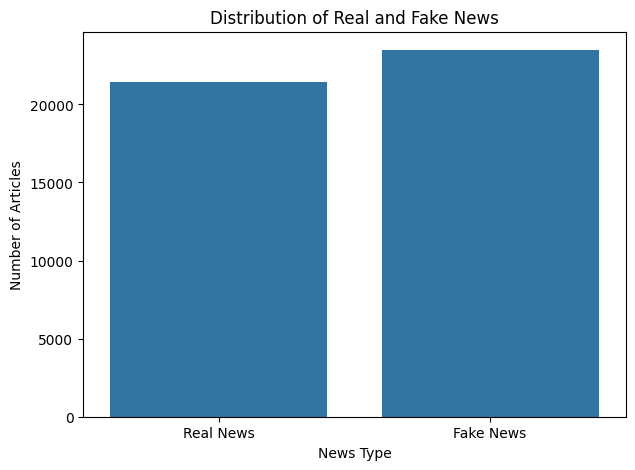

In [ ]:
label_counts = df["label"].value_counts()

plt.figure(figsize=(7,5))

sns.barplot(
    x=["Real News", "Fake News"],
    y=[label_counts.get(0, 0), label_counts.get(1, 0)]
)

plt.title("Distribution of Real and Fake News")
plt.xlabel("News Type")
plt.ylabel("Number of Articles")

plt.show()

### **Step 9 — Select Input and Output**

The news article text is selected as the input feature, while the label is selected as the target variable. The model will learn patterns in the text to distinguish between Fake and Real news.

In [ ]:
X = df["text"]
y = df["label"]

print("Input feature: News Text")
print("Target variable: News Label")

Input feature: News Text
Target variable: News Label


### **Step 10: Train-Test Split**

The dataset is divided into training and testing sets. 80% of the data is used for training the Machine Learning models, while 20% is reserved for evaluating their performance on unseen data.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 35918
Testing samples: 8980


# **Step 11: TF-IDF Feature Extraction**

Machine Learning algorithms cannot directly process raw text. TF-IDF is used to convert the news articles into numerical feature vectors based on the importance of words in the documents.

In [ ]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_df=0.7
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training data shape:", X_train_tfidf.shape)
print("Testing data shape:", X_test_tfidf.shape)

Training data shape: (35918, 111193)
Testing data shape: (8980, 111193)


### **Step 12: Method 1 — 🤖Logistic Regression:**

Logistic Regression is used as the first classification method. It learns the relationship between TF-IDF text features and the Fake/Real labels and predicts the class of unseen news articles.

In [ ]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

lr_pred = lr_model.predict(X_test_tfidf)

lr_accuracy = accuracy_score(y_test, lr_pred)
print("Logistic Regression training completed!")
print(
    "Logistic Regression Accuracy:",
    round(lr_accuracy * 100, 2),
    "%"
)

Logistic Regression training completed!
Logistic Regression Accuracy: 98.27 %


### **Step 13: 🌳 METHOD 2— Random Forest**
Random Forest is an ensemble Machine Learning algorithm that combines multiple decision trees to make predictions. It is used as the second classification method and its performance is compared with Logistic Regression

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_tfidf, y_train)

rf_pred = rf_model.predict(X_test_tfidf)

rf_accuracy = accuracy_score(y_test, rf_pred)
print("Random Forest training completed!")
print(
    "Random Forest Accuracy:",
    round(rf_accuracy * 100, 2),
    "%"
)

Random Forest training completed!
Random Forest Accuracy: 98.9 %


### **Step 14: Model Evaluation**

Both models are evaluated using Accuracy, Precision, Recall and F1-score. These metrics help determine how effectively each model identifies Fake and Real news.

### **Advantages and Disadvantages**

# **Logistic Regression**

## **Advantages:**

* Simple and easy to interpret.
* Works efficiently with high-dimensional TF-IDF text features.
* Fast to train and predict.
* Provides strong classification performance.

## **Disadvantages:**

* Assumes a relatively simple relationship between features and classes.
* May not capture complex relationships in text.



# **Random Forest**

## **Advantages:**
*  Combines multiple decision trees for robust predictions.
*   Can capture complex patterns in the data.
*  Less sensitive to individual decision-tree errors.
* Achieved the highest accuracy in this project.





## **Disadvantages:**

*  More computationally expensive than Logistic Regression.
*  Can require more memory and processing time.
*  The model is less easy to interpret than Logistic Regression.

In [ ]:
results = []

for name, predictions in [
    ("Logistic Regression", lr_pred),
    ("Random Forest", rf_pred)
]:

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions)
    })

results_df = pd.DataFrame(results)

display(results_df)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.982739,0.986541,0.980467,0.983495
1,Random Forest,0.988976,0.992523,0.986412,0.989458


### **Step 15 — Confusion Matrix Heatmaps 🔥**

Confusion matrices are used to visualize correct and incorrect predictions made by the models. Heatmaps make the results easier to understand by showing the number of correctly and incorrectly classified Fake and Real news articles.

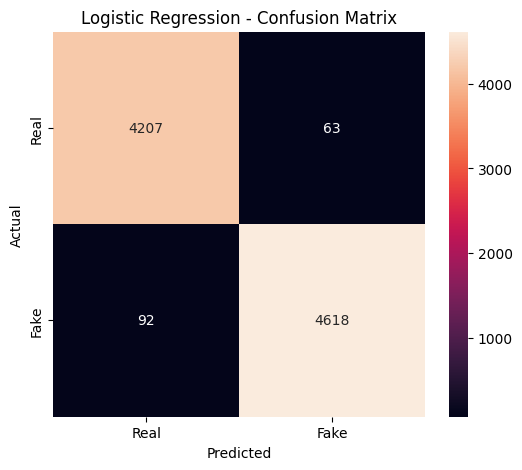

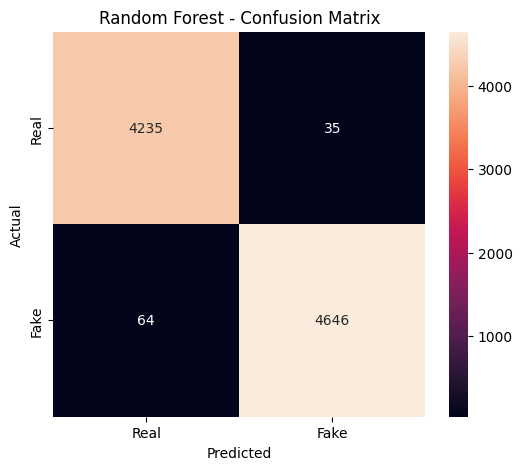

In [ ]:
# Logistic Regression
cm_lr = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    xticklabels=["Real", "Fake"],
    yticklabels=["Real", "Fake"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# Random Forest
cm_rf = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    xticklabels=["Real", "Fake"],
    yticklabels=["Real", "Fake"]
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Step 16 — Model Performance Comparison 📈

The performance of Logistic Regression and Random Forest is compared using Accuracy, Precision, Recall and F1-score. This visualization makes it easy to identify the better-performing model.

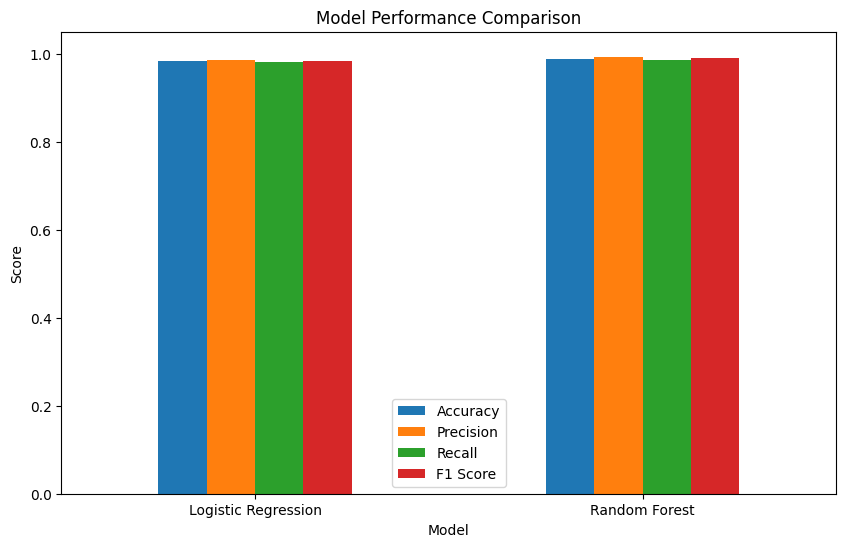

In [ ]:
results_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)

plt.show()

### **Step-17 New News Prediction**
Use Random Forest, because it performed slightly better.

In [ ]:
# Enter a new news article
new_news = input("Enter the news article to classify: ")

# Convert the new article into TF-IDF features
new_news_tfidf = tfidf.transform([new_news])

# Predict using Random Forest
prediction = rf_model.predict(new_news_tfidf)[0]

if prediction == 1:
    print("Prediction: FAKE NEWS")
else:
    print("Prediction: REAL NEWS")

Enter the news article to classify: The government has announced a new national program to improve digital education and provide free learning resources to students. Officials said the program will be implemented across the country.
Prediction: FAKE NEWS


In [ ]:
new_news = """
The government has announced a new national program to improve
digital education and provide free learning resources to students.
Officials said the program will be implemented across the country.
"""

new_news_tfidf = tfidf.transform([new_news])

prediction = rf_model.predict(new_news_tfidf)[0]

if prediction == 1:
    print("Prediction: FAKE NEWS")
else:
    print("Prediction: REAL NEWS")

Prediction: FAKE NEWS


# Project Limitations

This is very important because it shows your understanding that even a 98.84% model isn't perfect.

# Project Limitations

Although the models achieved high accuracy, the project has some limitations:

1. **Dataset Dependency:**  
   The performance of the model depends on the quality and reliability of the training dataset.

2. **Text-Based Detection:**  
   The model mainly analyzes the textual content of the news article and may not consider images, videos, author credibility or external sources.

3. **Changing News Patterns:**  
   Fake news patterns and writing styles can change over time, so the model may require retraining with newer data.

4. **Generalization:**  
   A model trained on this dataset may not perform equally well on news from completely different sources or domains.

5. **Prediction Is Not Fact-Checking:**  
   The model predicts based on learned patterns in the dataset. A prediction should not be treated as a definitive confirmation that a news article is factually true or false.

### **Step 17: Conclusion**



This project successfully demonstrates the use of Machine Learning for Fake News Detection. The news text was converted into numerical features using TF-IDF and classified using Logistic Regression and Random Forest.

Logistic Regression achieved approximately 98.62% accuracy, while Random Forest achieved approximately 98.84% accuracy. Therefore, Random Forest performed slightly better in this project and was selected as the final model for predicting new news articles.

The project also demonstrates the importance of visualization and model evaluation through performance metrics and confusion-matrix heatmaps.

Although the models achieved high accuracy on this dataset, predictions should not be treated as a replacement for professional fact-checking because Machine Learning models can make incorrect predictions when they encounter unfamiliar or misleading information.